Random Forest Accuracy: 0.8688524590163934

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



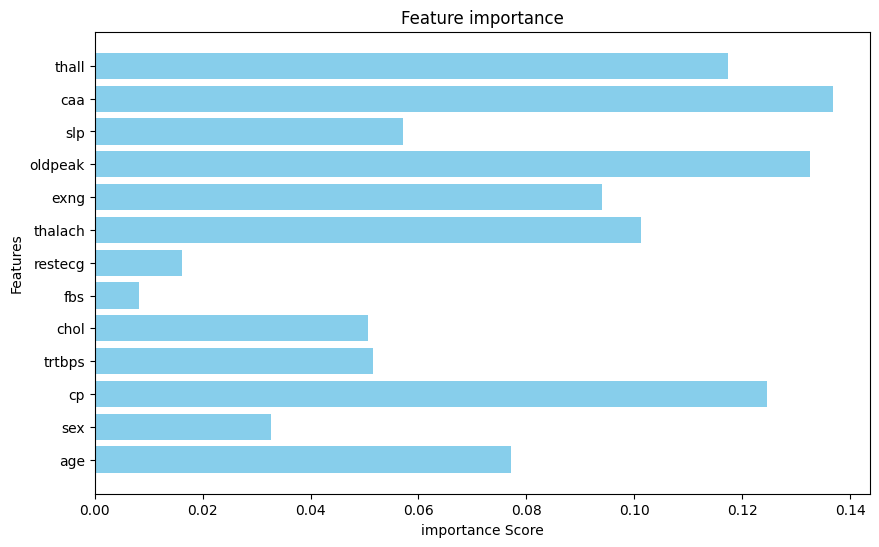

In [1]:
# 필요한 라이브러리 불러오기 
import pandas as pd # 데이터 처리 
from sklearn.model_selection import train_test_split # 데이터 분리 
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트 모델 
from sklearn.metrics import accuracy_score, classification_report # 평가 지표 
import matplotlib.pyplot as plt # 시각화

# 1. 데이터 로드 및 분리 
data = pd.read_csv('../datasets/heart.csv') # 데이터 로드 
X = data.drop('output', axis=1) # 입력 변수 
y = data['output'] # 출력 변수 (심장병 여부)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 데이터 분리

# 2. 랜덤 포레스트 모델 생성 및 학습 
rf_model = RandomForestClassifier( 
    n_estimators=100, # 100개의 의사결정 나무 
    max_depth=5, # 트리의 최대 깊이 제한 
    random_state=42 # 결과 재현성 유지 
) 
rf_model.fit(X_train, y_train) # 모델 학습

# 3. 테스트 데이터로 예측 
y_pred = rf_model.predict(X_test)

# 4. 모델 평가 
accuracy = accuracy_score(y_test, y_pred) # 정확도 계산 
report = classification_report(y_test, y_pred) # 정밀도, 재현율, F1-스코어

print("Random Forest Accuracy:", accuracy) 
print("\nClassification Report:\n", report)

# 5. 특성 중요도 시각화 
feature_importances = rf_model.feature_importances_ # 특성 중요도 계산 
features = X.columns

# 시각화 
plt.figure(figsize=(10, 6)) 
plt.barh(features, feature_importances, color='skyblue') 
plt.title("Feature importance") 
plt.xlabel("importance Score") 
plt.ylabel("Features") 
plt.show()